In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

print("="*80)
print("TITANIC SURVIVAL PREDICTION - CLASSIFICATION")
print("="*80)


TITANIC SURVIVAL PREDICTION - CLASSIFICATION


In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")




In [ ]:

print(df.head())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:

print(df.describe(include="all"))


        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.308642                  NaN   NaN   
std      257.353842    0.486592    0.836071                  NaN   NaN   
min        1.000000    0.000000    1.000000                  NaN   NaN   
25%      223.500000    0.000000    2.000000                  NaN   NaN   
50%      446.000000    0.000000    3.000000                  NaN   NaN   
75%      668.500000    1.000000    3.000000                  NaN   NaN   
max      891.000000    1.000000    3.000000                  NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare Cabin Embarked  
count   714.000000  891.000000 

In [ ]:

print("\nMissing Values")
print(df.isnull().sum())



Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df.drop(columns=["Cabin"], inplace=True, errors="ignore")

In [ ]:

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


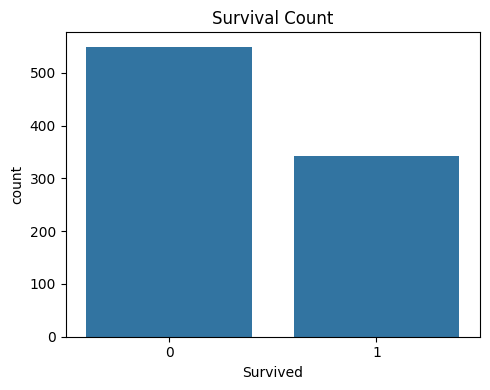

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count")
plt.tight_layout()
plt.show()



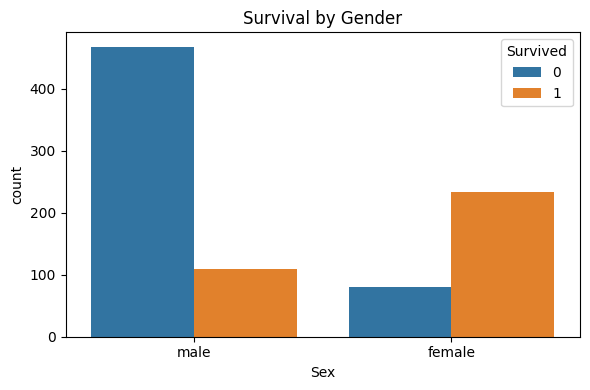

In [ ]:


plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.tight_layout()
plt.show()



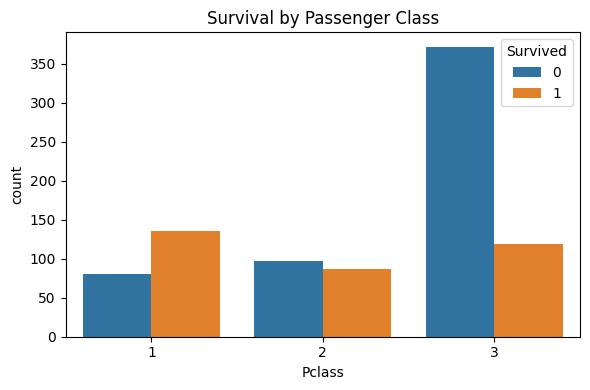

In [ ]:


plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.tight_layout()
plt.show()


In [ ]:
df["Sex"] = df["Sex"].map({"male":0,"female":1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)



In [ ]:

drop_cols = ["PassengerId","Name","Ticket","Survived"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["Survived"]



In [ ]:

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)



In [ ]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42)
}




------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy: 0.8045
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



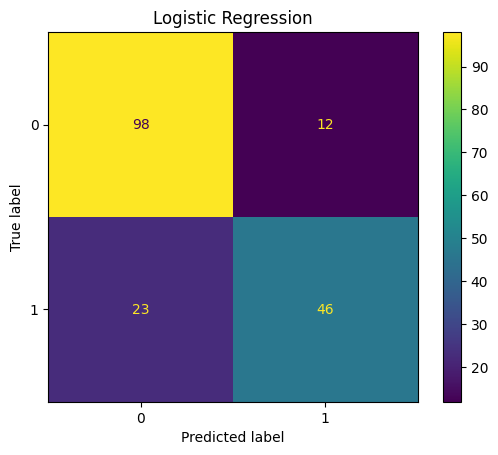


------------------------------------------------------------
Decision Tree
------------------------------------------------------------
Accuracy: 0.8212
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



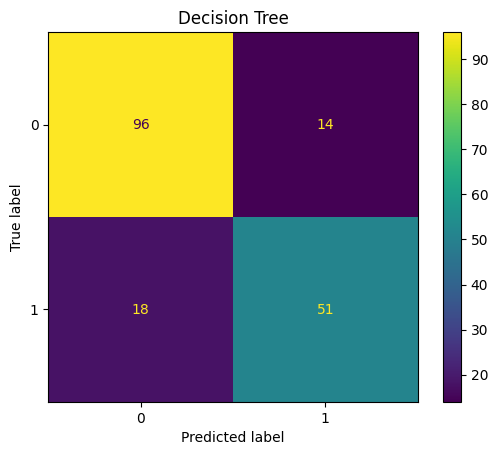


------------------------------------------------------------
Random Forest
------------------------------------------------------------
Accuracy: 0.8045
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



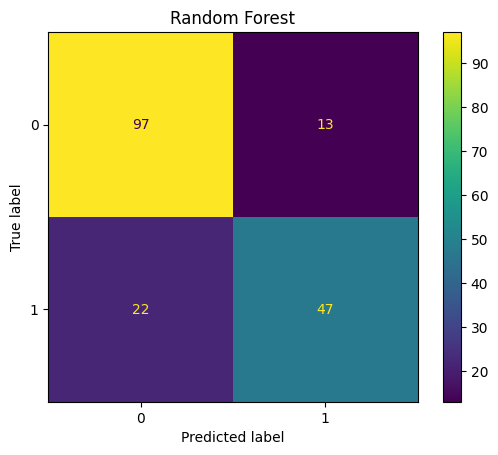


------------------------------------------------------------
KNN
------------------------------------------------------------
Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



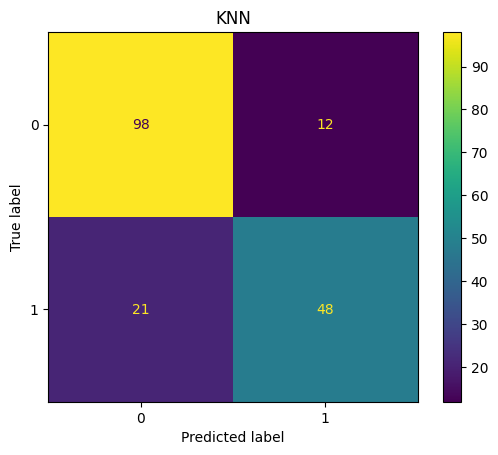


------------------------------------------------------------
SVM
------------------------------------------------------------
Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



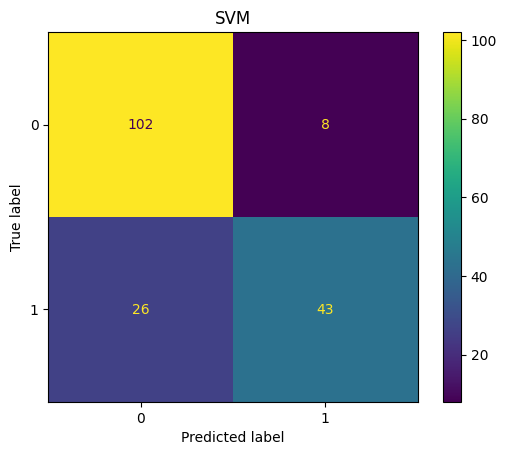

In [ ]:

results = []

for name, model in models.items():
    print("\n"+"-"*60)
    print(name)
    print("-"*60)

    model.fit(X_train,y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)
    results.append([name,acc])

    print("Accuracy:",round(acc,4))
    print(classification_report(y_test,pred))

    cm = confusion_matrix(y_test,pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(name)
    plt.show()



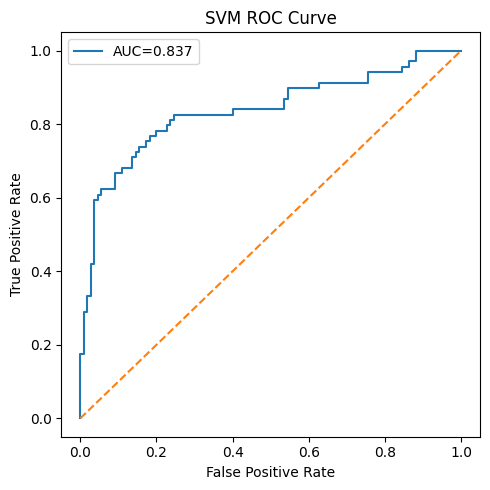

In [ ]:


    if hasattr(model,"predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
        fpr,tpr,_ = roc_curve(y_test,prob)
        roc_auc = auc(fpr,tpr)

        plt.figure(figsize=(5,5))
        plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],"--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(name+" ROC Curve")
        plt.legend()
        plt.tight_layout()
        plt.show()


Model Comparison
                 Model  Accuracy
1        Decision Tree  0.821229
3                  KNN  0.815642
4                  SVM  0.810056
0  Logistic Regression  0.804469
2        Random Forest  0.804469


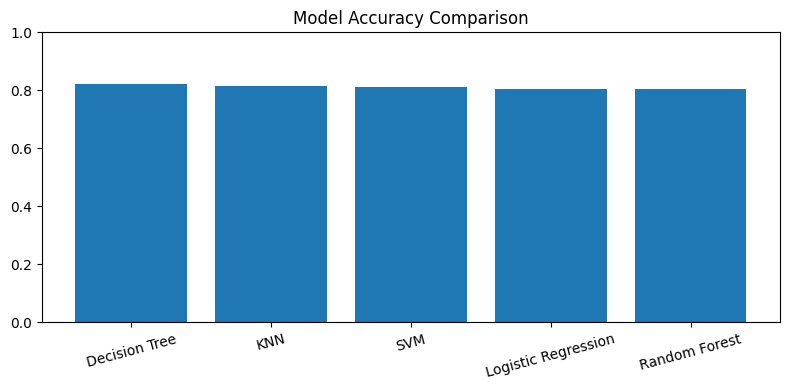

In [ ]:
result_df = pd.DataFrame(results,columns=["Model","Accuracy"])
result_df = result_df.sort_values("Accuracy",ascending=False)

print("\nModel Comparison")
print(result_df)

plt.figure(figsize=(8,4))
plt.bar(result_df["Model"],result_df["Accuracy"])
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()



In [ ]:

best_name = result_df.iloc[0]["Model"]
print("\nBest Model:",best_name)

best_model = models[best_name]
predictions = best_model.predict(X_test)

output = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":predictions
})

output.to_csv("Titanic_Predictions.csv",index=False)

print("\nPredictions saved as Titanic_Predictions.csv")

print("\nProgram Completed Successfully.")


Best Model: Decision Tree

Predictions saved as Titanic_Predictions.csv

Program Completed Successfully.
